In [1]:
import time
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Factorial (Recursive)
fact_calls = 0

def factorial(n):
    global fact_calls
    fact_calls += 1

    if n == 0 or n == 1:
        return 1
    return n * factorial(n - 1)

# Fibonacci (Naive Recursion)
fib_naive_calls = 0

def fib_naive(n):
    global fib_naive_calls
    fib_naive_calls += 1

    if n <= 1:
        return n
    return fib_naive(n - 1) + fib_naive(n - 2)

# Fibonacci (DP / Memoization)
fib_dp_calls = 0

def fib_dp(n, memo=None):
    global fib_dp_calls
    fib_dp_calls += 1

    if memo is None:
        memo = {}

    if n in memo:
        return memo[n]

    if n <= 1:
        return n

    memo[n] = fib_dp(n - 1, memo) + fib_dp(n - 2, memo)
    return memo[n]

In [3]:
def run_and_measure(func, n):
    start = time.perf_counter()
    value = func(n)
    end = time.perf_counter()
    return value, (end - start)

In [4]:
fact_inputs = [5, 10, 15, 20]
fib_inputs = [5, 10, 15, 20, 25, 30]  

results = []

# Factorial Results
for n in fact_inputs:
    fact_calls = 0
    val, t = run_and_measure(factorial, n)

    results.append({
        "Algorithm": "Factorial (Recursion)",
        "n": n,
        "Value": val,
        "Function Calls": fact_calls,
        "Time (sec)": t
    })

for n in fib_inputs:
    # Naive Fibonacci
    fib_naive_calls = 0
    val1, t1 = run_and_measure(fib_naive, n)

    results.append({
        "Algorithm": "Fibonacci (Naive)",
        "n": n,
        "Value": val1,
        "Function Calls": fib_naive_calls,
        "Time (sec)": t1
    })

    # DP Fibonacci
    fib_dp_calls = 0
    val2, t2 = run_and_measure(lambda x: fib_dp(x, {}), n)

    results.append({
        "Algorithm": "Fibonacci (DP)",
        "n": n,
        "Value": val2,
        "Function Calls": fib_dp_calls,
        "Time (sec)": t2
    })


In [6]:
df = pd.DataFrame(results)
print("\nTask 3 Table (Time + Calls):\n")
print(df)


Task 3 Table (Time + Calls):

                Algorithm   n                Value  Function Calls  Time (sec)
0   Factorial (Recursion)   5                  120               5    0.000003
1   Factorial (Recursion)  10              3628800              10    0.000001
2   Factorial (Recursion)  15        1307674368000              15    0.000002
3   Factorial (Recursion)  20  2432902008176640000              20    0.000002
4       Fibonacci (Naive)   5                    5              15    0.000003
5          Fibonacci (DP)   5                    5               9    0.000003
6       Fibonacci (Naive)  10                   55             177    0.000013
7          Fibonacci (DP)  10                   55              19    0.000003
8       Fibonacci (Naive)  15                  610            1973    0.000142
9          Fibonacci (DP)  15                  610              29    0.000004
10      Fibonacci (Naive)  20                 6765           21891    0.001578
11         Fibonacci 

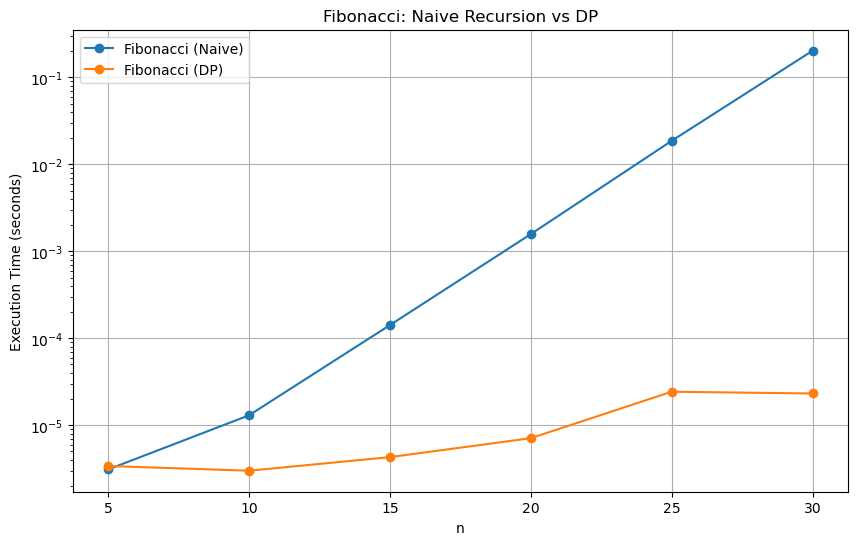

In [7]:
fib_df = df[df["Algorithm"].str.contains("Fibonacci")]

plt.figure(figsize=(10, 6))

for algo in fib_df["Algorithm"].unique():
    temp = fib_df[fib_df["Algorithm"] == algo]
    plt.plot(temp["n"], temp["Time (sec)"], marker="o", label=algo)

plt.xlabel("n")
plt.ylabel("Execution Time (seconds)")
plt.title("Fibonacci: Naive Recursion vs DP")
plt.legend()
plt.grid(True)

plt.yscale("log")   
plt.show()